# Schema for files

{
    "$schema": "http://json-schema.org/draft-04/schema#",
    "type": "object",
    "properties": {
        "name": {
            "type": "string"
        },
        "group": {
            "type": "string"
        },
        "metadata": {
            "type": "null"
        },
        "timers": {
            "type": "object",
            "properties": {
                "finished": {
                    "type": "string"
                },
                "started": {
                    "type": "string"
                },
                "vm-running": {
                    "type": "string"
                }
            },
            "required": [
                "finished",
                "started",
                "vm-running"
            ]
        },
        "metrics": {
            "type": "array",
            "items": [
                {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string"
                        },
                        "cpu": {
                            "type": "object",
                            "properties": {
                                "cores": {
                                    "type": "array",
                                    "items": [
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        }
                                    ]
                                },
                                "average": {
                                    "type": "number"
                                }
                            },
                            "required": [
                                "cores",
                                "average"
                            ]
                        },
                        "ram": {
                            "type": "number"
                        },
                        "disk": {
                            "type": "integer"
                        },
                        "timestamp": {
                            "type": "string"
                        }
                    },
                    "required": [
                        "name",
                        "cpu",
                        "ram",
                        "disk",
                        "timestamp"
                    ]
                }
            ]
        }
    },
    "required": [
        "name",
        "group",
        "metadata",
        "timers",
        "metrics"
    ]
}

In [48]:
# Install the required packages
%pip install matplotlib
%pip install Pillow
%pip install scipy
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [118]:
import os
import json
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib import lines
from scipy.interpolate import make_interp_spline
from scipy.interpolate import spline

import numpy as np
from itertools import groupby

RESULTS_DIR = 'results'

In [169]:
# Load results directory and parse out each test
def list_results():
    results = []

    results_files = os.listdir(RESULTS_DIR)
    for file in results_files:
        vmm, group, test, timestamp = file.removesuffix(".json").split('_', 3)
        
        # Parse content as json
        with open(f"{RESULTS_DIR}/{file}", "r") as f:
            content = f.read()
            json_content = json.loads(content)

        results.append({
            'vmm': vmm,
            'group': group,
            'test': test,
            # Parse from 2024-04-03-16-39-37 to datetime
            'timestamp': datetime.strptime(timestamp, "%Y-%m-%d-%H-%M-%S"),
            'data': json_content
        })


    return results        

results = list_results()

In [299]:
def merge_files(results, node_types):
    def merge_timers(results):
        merged_timers = {}
        for result in results:
            started = result['data']['timers']['started']
            for name, ts_list in result['data']['timers'].items():
                if name not in merged_timers:
                    merged_timers[name] = []

                diff = datetime.fromisoformat(ts_list) - datetime.fromisoformat(started)
                merged_timers[name].append(diff.total_seconds())

        for name, ts_list in merged_timers.items():
            merged_timers[name] = sum(ts_list) / len(ts_list)

        return merged_timers
        
    def combine_metrics(results):
        # We only care about cpu average, ram and disk

        all_metrics = []
        for result in results:
            all_metrics += result['data']['metrics']

        # Group by name
        node_groups = [(name, list(node_metrics)) for name, node_metrics in groupby(all_metrics, key=lambda x: x['name'])]
        node_groups = [(name, node_metrics) for name, node_metrics in node_groups if any(node_type in name for node_type in node_types)]

        return node_groups

    return (merge_timers(results), combine_metrics(results))


vmm = "kubevirt"
group = "create-each-type"
matches = [result for result in results if result['vmm'] == vmm and result['group'] == group]

merge_files(matches, ["control"])

({'finished': 15.490915000000001, 'started': 0.0, 'vm-running': 10.40760775},
 [('kubevirt-control-1',
   [{'name': 'kubevirt-control-1',
     'cpu': {'cores': [0.215, 0.2121, 0.2596, 0.2165, 0.17],
      'average': 0.21464000000000003},
     'ram': 0.110315,
     'disk': 0,
     'timestamp': '2024-04-03T14:37:21Z'},
    {'name': 'kubevirt-control-1',
     'cpu': {'cores': [0.0433, 0.02, 0.0521, 0.051, 0.0505],
      'average': 0.043379999999999995},
     'ram': 0.112844,
     'disk': 0,
     'timestamp': '2024-04-03T14:37:24Z'},
    {'name': 'kubevirt-control-1',
     'cpu': {'cores': [0.0979, 0.1134, 0.0938, 0.0918, 0.0928],
      'average': 0.09794},
     'ram': 0.111065,
     'disk': 0,
     'timestamp': '2024-04-03T14:37:26Z'},
    {'name': 'kubevirt-control-1',
     'cpu': {'cores': [0.1713, 0.1616, 0.19, 0.1485, 0.1856],
      'average': 0.17139999999999997},
     'ram': 0.113455,
     'disk': 0,
     'timestamp': '2024-04-03T14:37:28Z'},
    {'name': 'kubevirt-control-1',
     

In [ ]:
def _plot(ax, x_axises, y_axises, timers, vmm):
    max_y = 0
    min_y = 0
    for y_axis in y_axises:
        # Find its corresponding x axis by name
        x_axis = next((x for x in x_axises if x['node'] == y_axis['node']), None)
        # Convert to numpy arrays
        x_axis['data'] = np.array(x_axis['data'])
        y_axis['data'] = np.array(y_axis['data'])

        # Create smooth spline
        X_Y_Spline = make_interp_spline(x_axis['data'], y_axis['data'], k=3)

        # Generate new x values (numeric)
        X_ = np.linspace(x_axis['data'].min(), x_axis['data'].max(), 20)
        # Generate new y values using the spline
        Y_ = X_Y_Spline(X_)        
        
        ax.plot(X_, Y_, label=y_axis['label'])

        max_y = max(max_y, y_axis['data'].max())
        min_y = min(min_y, y_axis['data'].min())

    # Plot timers
    for name, val in timers.items():
        # Skip started
        if name == 'started':
            continue            
        
        label = vmm + " " + name
        
        ax.plot([val, val],[min_y, max_y], label=label, linestyle='--')


def _get_x_axis(node_groups):
    x_axises = []

    for name, node_metrics in node_groups:
        # Assume sorted by timestamp
        first_ts = datetime.fromisoformat(node_metrics[0]['timestamp'])

        x_axis = []
        for metric in node_metrics:
            ts = datetime.fromisoformat(metric['timestamp'])
            sec_from_start = (ts - first_ts).total_seconds()
            x_axis.append(sec_from_start)
        x_axises.append({"node": name, "data": x_axis})

    return x_axises

def _get_y_axis(node_groups, utilizations, should_label=False):
    y_axises = []

    utilization_label = None
    if should_label:
        utilization_label = vmm

    for utilization in utilizations:
        if utilization == 'cpu':
            for name, node_metrics in node_groups:
                cpu = []
                for metric in node_metrics:
                    cpu.append(metric['cpu']['average'])
                y_axises.append({"node": name, "label": utilization_label, "data": cpu})
        elif utilization == 'ram':
            for name, node_metrics in node_groups:
                ram = []
                for metric in node_metrics:
                    ram.append(metric['ram'])
                y_axises.append({"node": name, "label": utilization_label, "data": ram})
        elif utilization == 'disk':
            for name, node_metrics in node_groups:
                disk = []
                for metric in node_metrics:
                    disk.append(metric['disk'])
                y_axises.append({"node": name, "label": utilization_label, "data": disk})
        else:
            print(f"Unknown utilization {utilization}")
            return

    return y_axises

In [332]:
# Create plots
def plot_results(vmms, group, test, node_types, utiliazations):
    # Remove any utilization that is not 'cpu', 'ram' or 'disk'
    utiliazations = [utiliazation for utiliazation in utiliazations if utiliazation in ['cpu', 'ram', 'disk']]

    fig, ax = plt.subplots()
    ax.set_title(f"{test} ({', '.join(utiliazations)})")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Utilization (%)')


    # 1. Find result with group and test, choose latest if multiple
    for vmm in vmms:
        matches = [result for result in results if result['vmm'] == vmm and result['group'] == group and result['test'] == test]
        if len(matches) == 0:
            print(f"No results found for {vmm}/{group}/{test}")
            return
        
        timers, node_groups = merge_files(matches, node_types)
    
        # Extract X axis values
        x_axises = _get_x_axis(node_groups)
        x_timers = timers

        # Extract Y axis values
        y_axises = _get_y_axis(node_groups, utiliazations, should_label=len(vmms) > 1)
        
        _plot(ax, x_axises, y_axises, x_timers, vmm)  

    ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.show()


## Create each type

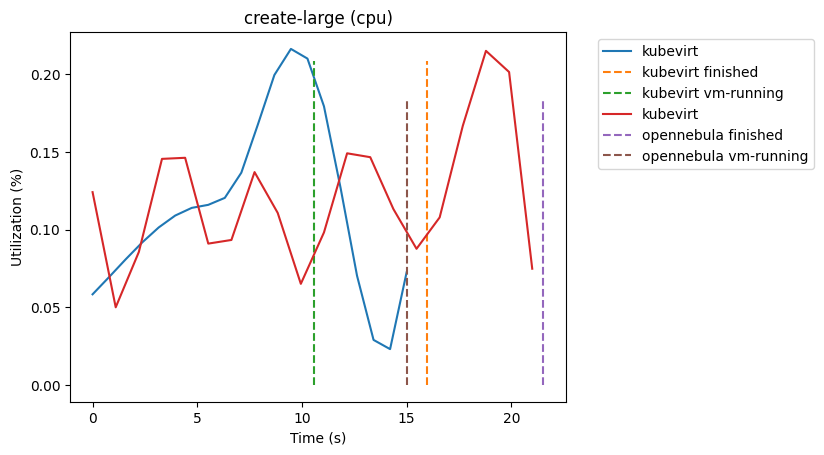

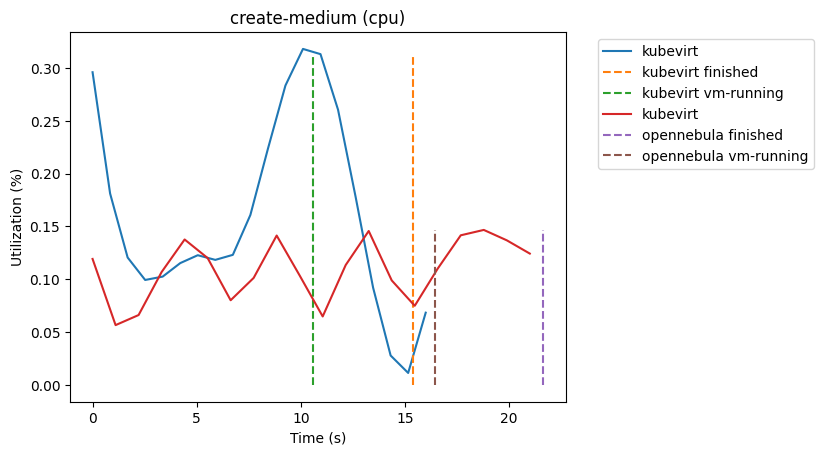

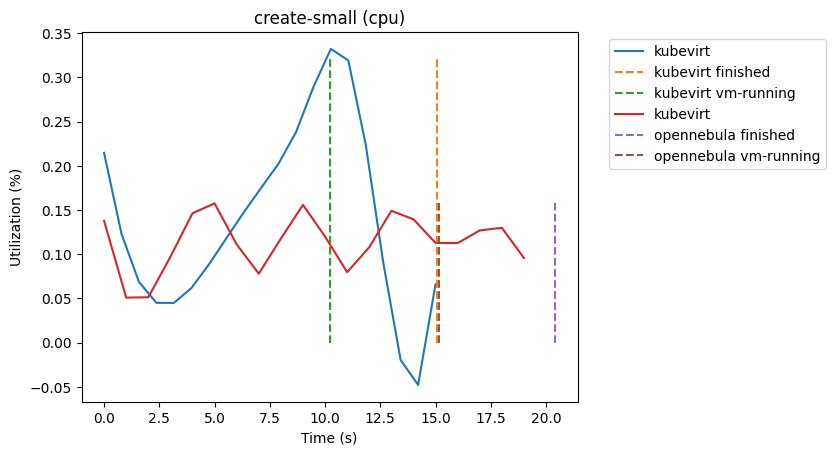

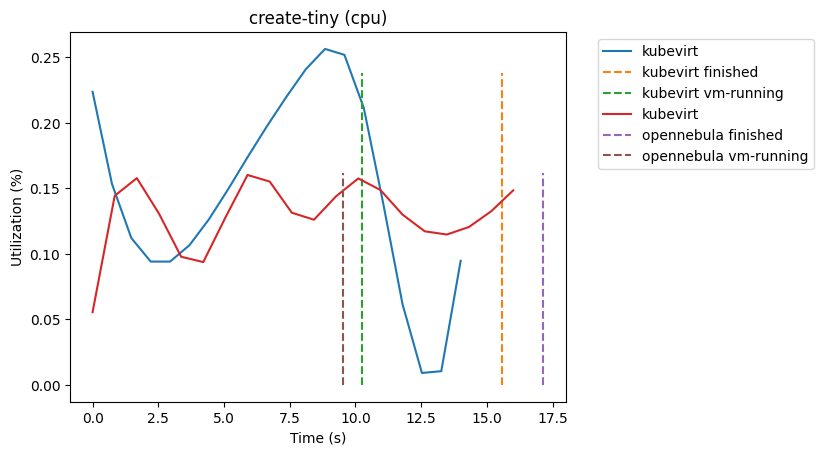

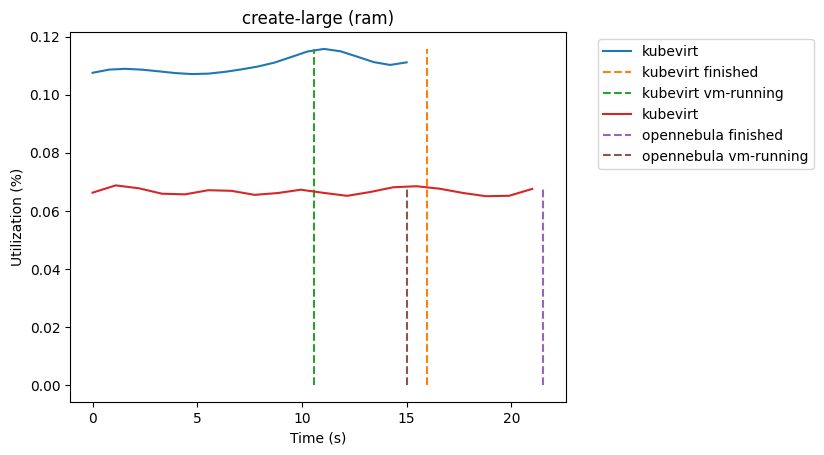

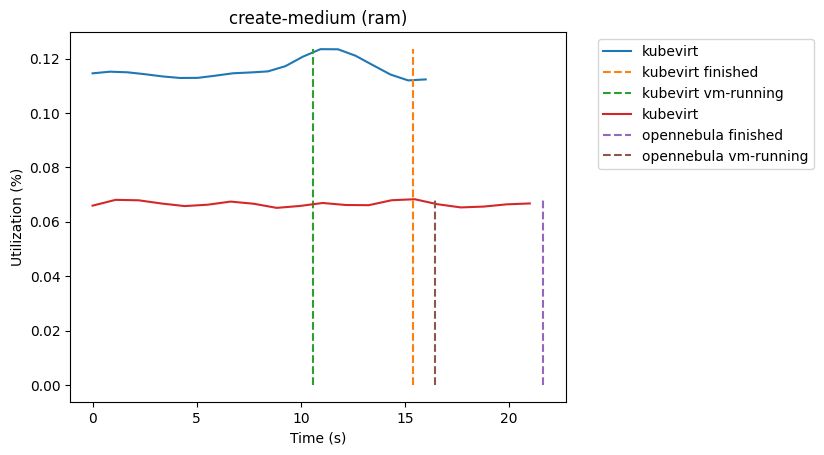

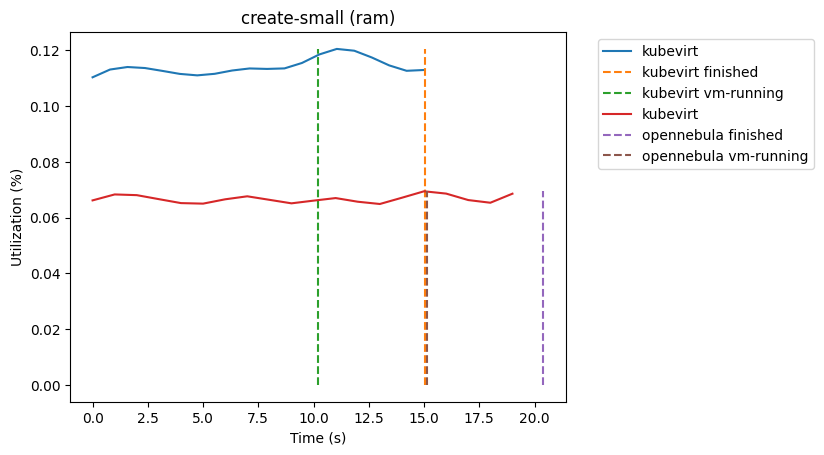

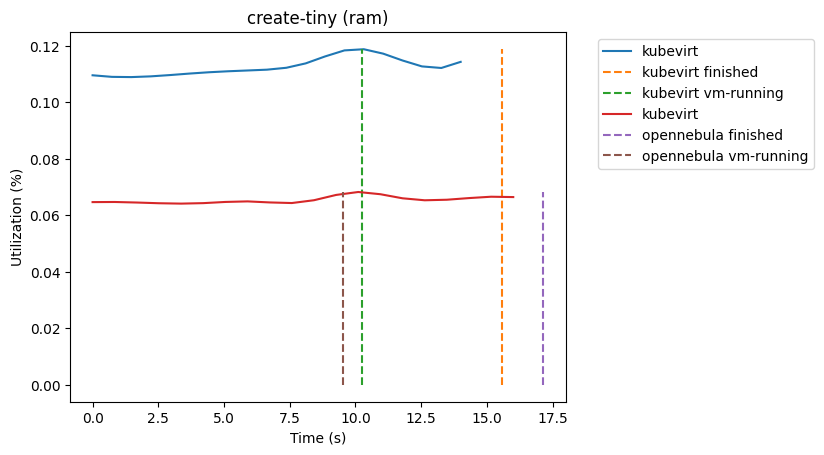

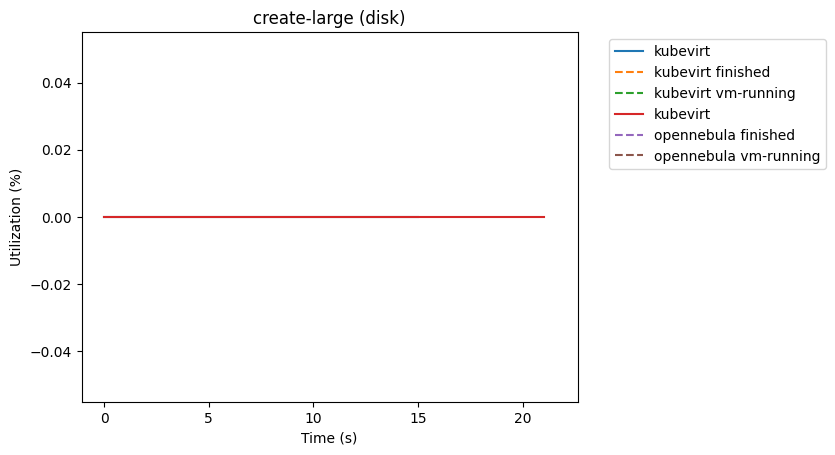

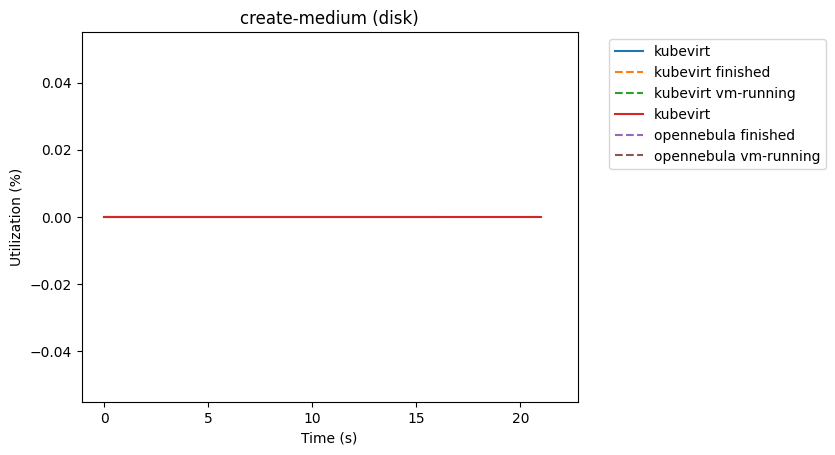

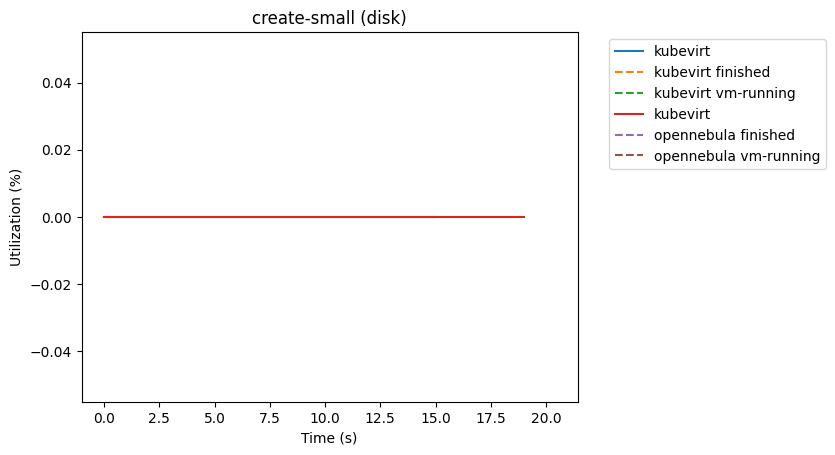

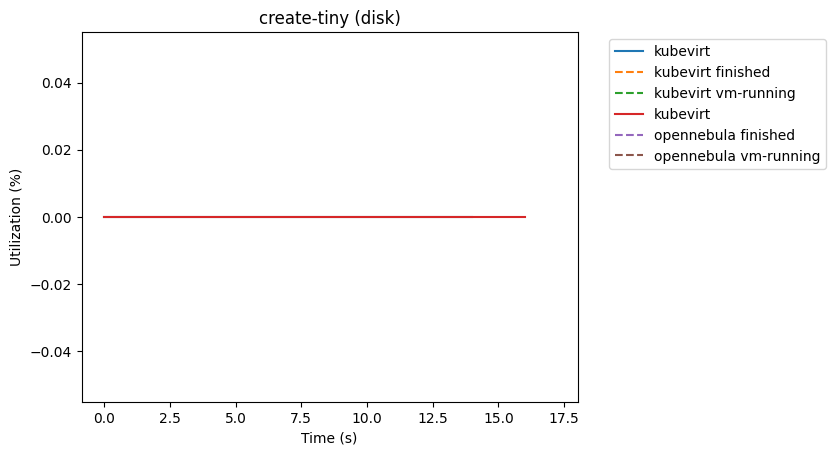

In [334]:
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-large', ['control'], ['cpu'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-medium', ['control'], ['cpu'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-small', ['control'], ['cpu'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-tiny', ['control'], ['cpu'])

plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-large', ['control'], ['ram'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-medium', ['control'], ['ram'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-small', ['control'], ['ram'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-tiny', ['control'], ['ram'])

plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-large', ['control'], ['disk'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-medium', ['control'], ['disk'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-small', ['control'], ['disk'])
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-tiny', ['control'], ['disk'])



## Create many tiny

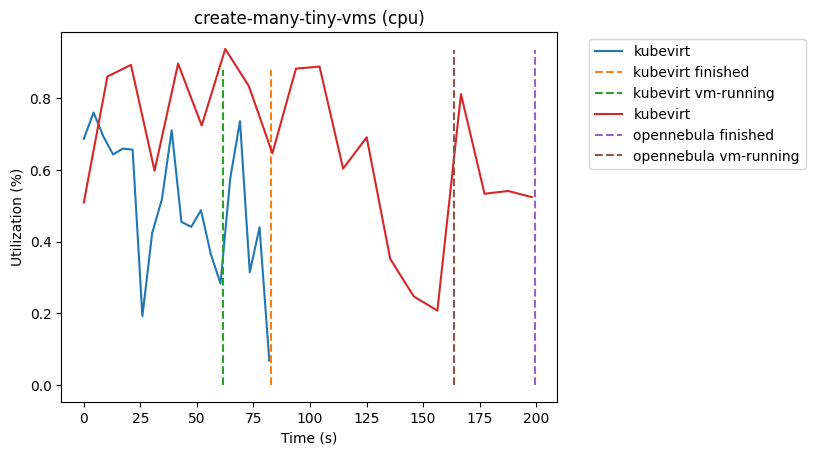

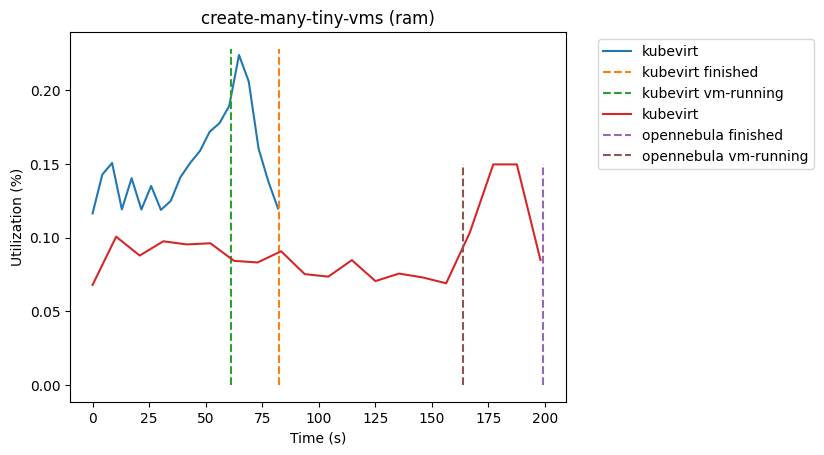

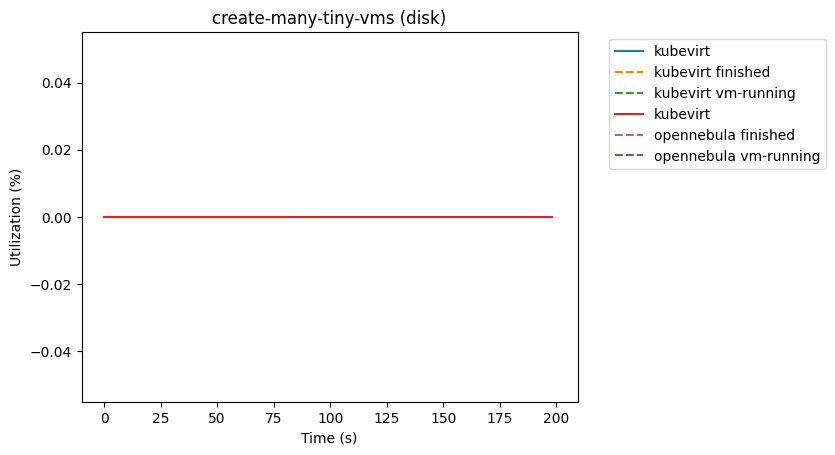

In [336]:
plot_results(['kubevirt', 'opennebula'],'create-many-tiny-vms', 'create-many-tiny-vms', ['control'], ['cpu'])
plot_results(['kubevirt', 'opennebula'],'create-many-tiny-vms', 'create-many-tiny-vms', ['control'], ['ram'])
plot_results(['kubevirt', 'opennebula'],'create-many-tiny-vms', 'create-many-tiny-vms', ['control'], ['disk'])
